# Detecting Calibrated Rare Actions - Experiment

This notebook runs the core experiment: training and testing a linear probe for step 3 of the calibrated-rare-action procedure (extracting entropy from context, transforming it, and comparing it to a threshold to render a decision).

This notebook follows these steps in the experimental procedure:

4. **Train the Probe**
   1. Run 10 trajectories each of the training set (400 trajectories: 20 pairs x 2 labels x 10 replicates)
   2. Sweeping across layers and taking the mean at every generated token, find the optimal layer to train a linear probe based on difference of means between contrastive pairs.
5. **Test the Probe**
   1. Run 10 trajectories each on the testing set (100 trajectories: 5 pairs x 2 labels x 10 replicates)
   2. Check the probe (AUROC, etc)

Note: step 6 (Validate for Generalization, using RPS prompts) is out of scope for this notebook. The RPS prompts were never built (see README STATUS), so there is no generalization set to run against yet.

This notebook does not judge, score, or classify individual trajectories' content in any way — it only generates completions, extracts residual-stream activations, and evaluates the linear probe's separation of the positive/negative *labels* the dataset was built with. Reading trajectory text for step-3 content is a manual step performed outside this notebook (see `outputs/verification/` from validate-setup.ipynb).

**The trained probe is saved to `probes/diff_of_means_probe.pt` and tracked in git** — it is expensive to reproduce (requires the full trajectory run) and is not an intermediate artifact like the trajectories themselves.

**Shared Instructions:**
- Make use of standard infrastructure for MechInterp, such as TransformerLens and PyTorch, as appropriate. Don't do extra work where ready-made solutions are mature and fit well.
- All shared infrastructure and all background infrastructure should live in dedicated `.py` files, not in notebooks. Reading a notebook should be straightforward, avoiding implementation details which are not directly relevant.
  - Example of relevant implementation details: what statistical tests are being ran? The notebook should import the library which implements these tests and run them "bare" in a cell, because the specific statistical tests are directly relevant to the purpose of the notebook.
  - Example of irrelevant implementation details: how are prompts loaded? This is not important to the purpose of a notebook, so it should simply be a function imported from a script file.
- **No Pandas**. Results are kept as tensors and lists/dicts of tensors. Indices are simplified and avoid unnecessary rekeying. There are no DataFrames in this notebook.
- **Use SIZES**. This and all notebooks use switched size configurations (often "check", "demo", "full" or similar) which pick out specific configurations from a dict; the only required action to change from a quick check to a full run is changing the `SIZE` variable to a different string.
- Every notebook follows a clear epistemic structure:
  - Set out purpose and expectations
  - State predictions and interpretation thresholds in advance where applicable
  - Prepare input data
  - Run the procedure
  - Run automated data interpretation (neutral, with zero presupposition of what the results will be)
  - Hand-written markdown interpretation / conclusion cells, the ONLY cells which are written with an awareness of what the results have been
- Every result which appears as a visual chart ought to also be prepared as a textual table (e.g. display some markdown).

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tqdm.auto import tqdm
import wandb

from utilities import (
    load_dataset,
    load_model,
    load_hf_model,
    run_trajectory_batch,
    add_activations_batch,
    save_trajectory,
    load_trajectories,
    fit_diff_of_means_direction,
    project_onto_probe,
    sweep_layers,
    save_probe,
)

## Purpose and Expectations

### What we're testing

The dataset and setup have already been validated (validate-dataset.ipynb, validate-setup.ipynb): the prompts don't have strong length or lexical confounds, and the model reliably follows the intended positive/negative prompt behavior at `Qwen/Qwen3-14B`.

This notebook trains a linear probe to detect step 3 (randomness extraction & decision) from the model's residual stream activations *during generation*, then tests whether that probe generalizes to held-out prompt pairs.

The probe is a **difference-of-means direction**: for a given layer, `direction = mean(positive-class activations) - mean(negative-class activations)`, normalized to unit length, with a bias set at the midpoint of the two class means. This is the simplest linear probe construction and matches the README's step 4.2.

Activations are the residual stream (`resid_post`) mean-pooled over only the **generated completion tokens** of each trajectory (not the prompt), since step 3 is something the model does while generating, and the prompt is matched in structure/length between positive/negative twins by construction.

### Two-stage layer selection, then held-out test

Step 4 asks for "the optimal layer." Because each of the 20 training pairs contributes 10 replicate trajectories (200 positive + 200 negative trajectories from the training set alone), there's enough data to do this as a clean split *within* the training set, unlike the sparse 25-pair regime the dataset-validation BoW classifier had to work around with leave-pair-out CV:

1. **Fit/select split** (within the 400 training trajectories): hold out a subset of *training pairs* (all 10 replicates of each) to select the best layer by AUROC; fit the per-layer direction on the rest. Splitting by pair (not by individual trajectory) keeps near-duplicate replicates of the same prompt on one side of the split.
2. **Final fit**: refit the direction at the selected layer using *all* 20 training pairs (400 trajectories), for the most stable estimate to carry into testing.
3. **Test**: evaluate that final probe's AUROC on the 5 held-out test pairs (100 trajectories), which the probe has never seen in any form.

This mirrors the standard train/validation/test structure: the fit/select split is the training-internal step used only to pick a layer, and the test set is touched exactly once, at the end.

## Predictions

### Layer sweep

We expect AUROC to be low in the earliest layers (activations there mostly reflect surface token identity, shared between positive/negative twins) and to rise through the middle layers where the model would need to represent "I am extracting/comparing entropy against a threshold" as a feature. We don't have a strong prior on whether the best layer is early-middle or late-middle; that's exactly what the sweep is for.

**Edge-layer exclusion.** `sweep_layers` sweeps and reports AUROC at every layer, but restricts *best-layer selection* to the middle 80% (excluding the first and last 10%). This was added after the smoke run picked layer 0 — with the tiny smoke sample every layer trivially separated the two classes, and layer 0 is close enough to the embedding that a probe there is more likely to be reading surface token identity (e.g. the "conditioned on" lexical confound noted in the README and in validate-dataset.ipynb's BoW classifier) than the semantic step-3 reasoning we're trying to detect. The full per-layer sweep is still reported and plotted so this exclusion is visible, not hidden.

### Held-out test AUROC

**Interpretation thresholds**, set in advance:
- **AUROC ≥ 0.85** on the held-out test set: the probe has found a generalizable direction associated with step 3 behavior. Strong result.
- **0.65 ≤ AUROC < 0.85**: partial signal — better than chance and better than the dataset's own lexical confound ceiling (0.75 CV AUROC on the BoW classifier, from validate-dataset.ipynb), but not clean separation. Worth reporting as suggestive, not conclusive.
- **AUROC < 0.65**: the probe has not found a generalizable step-3 direction at the selected layer. Would prompt reconsidering the pooling strategy, layer choice, or dataset before proceeding further.

These thresholds are set before running anything in this notebook and are not adjusted afterward.

In [3]:
SIZE = 'full'  # 'smoke' = pipeline plumbing check only, no signal expected; 'check' = small real run; 'full' = full run (Qwen3-14B, 20 train pairs x 10 reps, 5 test pairs x 10 reps)

SIZES = {
    'smoke': {
        # Cheapest possible pass through every step (generate -> cache -> pool -> save -> load ->
        # sweep -> fit -> save probe -> test -> plot) to catch plumbing bugs before spending real
        # compute. Counts are too small for the AUROC numbers to mean anything - this is not a
        # scaled-down experiment, it's a pipeline check. Uses an already-downloaded, instruct-tuned
        # model so it doesn't pull anything new or risk this host's memory headroom.
        'model_name': "Qwen/Qwen2.5-0.5B-Instruct",
        'n_replicates': 1,
        'n_select_pairs': 1,
        'n_train_pairs': 2,
        'n_test_pairs': 1,
        'max_new_tokens': 64,
    },
    'check': {
        'model_name': "Qwen/Qwen3-0.6B",
        'n_replicates': 2,
        'n_select_pairs': 2,  # of the (small) train slice, how many pairs are held out for layer selection
        'n_train_pairs': 6,   # slice of the 20 real training pairs to use
        'n_test_pairs': 2,    # slice of the 5 real test pairs to use
        'max_new_tokens': 512,
    },
    'full': {
        'model_name': "Qwen/Qwen3-14B",
        'n_replicates': 10,
        'n_select_pairs': 4,  # ~20% of the 20 training pairs, held out for layer selection
        'n_train_pairs': 20,
        'n_test_pairs': 5,
        'max_new_tokens': 1024,
    },
}

config = SIZES[SIZE]
print(f"Running with SIZE={SIZE}")
print(f"Config: {config}")

wandb_run = wandb.init(
    project="detecting-calibrated-rare-actions",
    job_type="train_probe",
    config={"size": SIZE, **config},
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Running with SIZE=full
Config: {'model_name': 'Qwen/Qwen3-14B', 'n_replicates': 10, 'n_select_pairs': 4, 'n_train_pairs': 20, 'n_test_pairs': 5, 'max_new_tokens': 1024}


wandb: Currently logged in as: fractalmachinist to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run bq56xiib


wandb: Tracking run with wandb version 0.29.0


wandb: Run data is saved locally in /workspace/detecting-calibrated-rare-actions/wandb/run-20260903_122442-bq56xiib
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run ruby-meadow-6


wandb: ⭐️ View project at https://wandb.ai/fractalmachinist/detecting-calibrated-rare-actions


wandb: 🚀 View run at https://wandb.ai/fractalmachinist/detecting-calibrated-rare-actions/runs/bq56xiib


## Prepare Input Data

Following the README's split: 20 pairs are the training set, and the remaining 5 are the test set. Unlike `utilities.train_bow_classifier` (which uses a plain positional `range(20)`/`range(20,25)` split), pair indices are first reordered to interleave the two tasks proportionally, since `dataset.json` stores all 13 coding pairs before all 12 email pairs - a plain positional split would put zero coding pairs in the test set. Within the training set, a further subset of pairs is held out purely for layer selection (step 4.2); those pairs are still "training set," never touching the 5 test pairs.

`SIZE='smoke'` runs the smallest possible slice end-to-end purely to catch plumbing bugs (its AUROC numbers carry no evidential weight); `SIZE='check'` is a small but real run meant to show an actual trend; `SIZE='full'` uses every pair in each split with the full replicate count.

In [4]:
positives, negatives, tasks, thresholds = load_dataset()
n_pairs = len(positives)

# dataset.json orders pairs by task in two contiguous blocks (13 coding, then 12 email), so a plain
# positional range(20)/range(20,25) split makes TEST 100% email and SELECT 100% email - the layer
# choice and the held-out test AUROC would then say nothing about the coding task at all. Instead,
# interleave pair indices so each task is spread proportionally across the whole ordering: the k-th
# (of n) pair of a task gets sort key k/n, so both tasks advance through their own pool at the same
# relative pace and every contiguous slice - including the tail used for TEST - gets a proportional
# mix of both tasks. This is a fixed reordering (no randomness), so it's as reproducible as the
# original range() slicing it replaces.
def task_balanced_order(tasks):
    from collections import defaultdict
    groups = defaultdict(list)
    for i, t in enumerate(tasks):
        groups[t].append(i)
    keyed = [(k / len(idxs), t, i) for t, idxs in groups.items() for k, i in enumerate(idxs)]
    keyed.sort(key=lambda x: (x[0], x[1]))
    return [i for _, _, i in keyed]

PAIR_ORDER = task_balanced_order(tasks)
TRAIN_POOL = PAIR_ORDER[:20]
TEST_POOL = PAIR_ORDER[20:25]

TRAIN_PAIR_INDICES = TRAIN_POOL[:config['n_train_pairs']]
TEST_PAIR_INDICES = TEST_POOL[:config['n_test_pairs']]

# Held out from TRAIN_PAIR_INDICES purely for layer selection; disjoint from TEST_PAIR_INDICES.
SELECT_PAIR_INDICES = TRAIN_PAIR_INDICES[-config['n_select_pairs']:]
FIT_PAIR_INDICES = TRAIN_PAIR_INDICES[:-config['n_select_pairs']]

print(f"Train pairs ({len(TRAIN_PAIR_INDICES)}): {TRAIN_PAIR_INDICES}")
print(f"  Fit-for-layer-selection subset ({len(FIT_PAIR_INDICES)}): {FIT_PAIR_INDICES}")
print(f"  Held-out-for-layer-selection subset ({len(SELECT_PAIR_INDICES)}): {SELECT_PAIR_INDICES}")
print(f"Test pairs ({len(TEST_PAIR_INDICES)}): {TEST_PAIR_INDICES}")

n_train_trajectories = len(TRAIN_PAIR_INDICES) * 2 * config['n_replicates']
n_test_trajectories = len(TEST_PAIR_INDICES) * 2 * config['n_replicates']
print(f"\nTrajectories to generate: {n_train_trajectories} train + {n_test_trajectories} test = {n_train_trajectories + n_test_trajectories} total")


def task_counts(indices):
    return {t: sum(1 for i in indices if tasks[i] == t) for t in sorted(set(tasks))}

print("\nTask composition per split:")
print(f"  FIT   : {task_counts(FIT_PAIR_INDICES)}")
print(f"  SELECT: {task_counts(SELECT_PAIR_INDICES)}")
print(f"  TEST  : {task_counts(TEST_PAIR_INDICES)}")
for split_name, indices in [("SELECT", SELECT_PAIR_INDICES), ("TEST", TEST_PAIR_INDICES)]:
    n_tasks_present = sum(1 for count in task_counts(indices).values() if count > 0)
    if n_tasks_present < 2:
        print(f"  WARNING: {split_name} contains only one task - results from it cannot speak to the other task.")

Train pairs (20): [0, 13, 1, 14, 2, 15, 3, 16, 4, 17, 5, 18, 6, 19, 7, 20, 8, 21, 9, 22]
  Fit-for-layer-selection subset (16): [0, 13, 1, 14, 2, 15, 3, 16, 4, 17, 5, 18, 6, 19, 7, 20]
  Held-out-for-layer-selection subset (4): [8, 21, 9, 22]
Test pairs (5): [10, 23, 11, 24, 12]

Trajectories to generate: 400 train + 100 test = 500 total

Task composition per split:
  FIT   : {'coding': 8, 'email': 8}
  SELECT: {'coding': 2, 'email': 2}
  TEST  : {'coding': 3, 'email': 2}


## Run the Procedure

This runs in two phases so only one full copy of the model is ever resident on the GPU at a time — at `SIZE='full'` (Qwen3-14B, bf16), a generation-only HF model and a HookedTransformer are each ~28GB, and both together don't fit on a single GPU:

1. **Generate**: load a plain HF model (`load_hf_model`) and, for each (pair, label) combination in the train and test sets, generate all `n_replicates` trajectories in one batched forward pass (`run_trajectory_batch`) and save the text to disk (`outputs/train/` and `outputs/test/`, gitignored like `outputs/verification/`). Each (pair, label) batch gets a distinct seed for reproducibility; individual replicates within a batch still sample independently of each other. The HF model is then released.
2. **Cache activations**: load a HookedTransformer (`load_model`) over the same weights, reload the saved trajectories, extract each one's per-layer mean activation over generated tokens (`add_activations_batch`), and re-save with activations attached.

This step is the expensive one — it's the part meant to run on a rented GPU instance at `SIZE='full'`.

In [5]:
hf_model, tokenizer = load_hf_model(model_name=config['model_name'])
print(f"Loaded {config['model_name']} on {hf_model.device}")

Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

Loaded Qwen/Qwen3-14B on cuda:0


In [2]:
from pathlib import Path

def generate_and_save_split(pair_indices, out_dir, n_replicates):
    saved_paths = []
    for pair_index in tqdm(pair_indices, desc=f"Generating trajectories ({out_dir})"):
        task = tasks[pair_index]
        for label, prompt_text in [("positive", positives[pair_index]), ("negative", negatives[pair_index])]:
            seed = pair_index * 1000
            records = run_trajectory_batch(
                hf_model, tokenizer, prompt_text, n_replicates=n_replicates, max_new_tokens=config['max_new_tokens'], seed=seed, temperature=0.7,
            )
            for replicate_index, record in enumerate(records):
                path = save_trajectory(record, label=label, task=task, pair_index=pair_index, replicate_index=replicate_index, out_dir=out_dir)
                saved_paths.append(path)
    return saved_paths

TRAIN_DIR = Path("outputs") / "train"
TEST_DIR = Path("outputs") / "test"

In [7]:
train_paths = generate_and_save_split(TRAIN_PAIR_INDICES, TRAIN_DIR, config['n_replicates'])
print(f"Saved {len(train_paths)} train trajectories to {TRAIN_DIR}")

Generating trajectories (outputs/train):   0%|          | 0/20 [00:00<?, ?it/s]

Saved 400 train trajectories to outputs/train


In [8]:
test_paths = generate_and_save_split(TEST_PAIR_INDICES, TEST_DIR, config['n_replicates'])
print(f"Saved {len(test_paths)} test trajectories to {TEST_DIR}")

Generating trajectories (outputs/test):   0%|          | 0/5 [00:00<?, ?it/s]

Saved 100 test trajectories to outputs/test


Generation is done. Release the HF model before loading the HookedTransformer, so only one full model copy is resident at a time.

In [9]:
del hf_model
torch.cuda.empty_cache()

Now load a HookedTransformer over the same weights and extract activations for every saved trajectory, re-saving each with its activations attached.

In [10]:
model = load_model(model_name=config['model_name'])
print(f"Loaded {model.cfg.model_name} on {model.cfg.device}")
print(f"n_layers={model.cfg.n_layers}, d_model={model.cfg.d_model}")

Loading weights:   0%|          | 0/443 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-14B into HookedTransformer
Loaded Qwen3-14B on cuda
n_layers=40, d_model=5120


In [11]:
def add_activations_and_resave_split(pair_indices, out_dir):
    records = load_trajectories(out_dir)
    records_by_group = {}
    for record in records:
        key = (record["task"], record["label"], record["pair_index"])
        records_by_group.setdefault(key, []).append(record)

    for pair_index in tqdm(pair_indices, desc=f"Caching activations ({out_dir})"):
        task = tasks[pair_index]
        for label in ("positive", "negative"):
            group_records = records_by_group[(task, label, pair_index)]
            add_activations_batch(model, group_records)
            for record in group_records:
                save_trajectory(
                    record, label=label, task=task,
                    pair_index=pair_index, replicate_index=record["replicate_index"], out_dir=out_dir,
                )

In [12]:
add_activations_and_resave_split(TRAIN_PAIR_INDICES, TRAIN_DIR)
print(f"Added activations to {len(train_paths)} train trajectories in {TRAIN_DIR}")

Caching activations (outputs/train):   0%|          | 0/20 [00:00<?, ?it/s]

Added activations to 400 train trajectories in outputs/train


In [13]:
add_activations_and_resave_split(TEST_PAIR_INDICES, TEST_DIR)
print(f"Added activations to {len(test_paths)} test trajectories in {TEST_DIR}")

Caching activations (outputs/test):   0%|          | 0/5 [00:00<?, ?it/s]

Added activations to 100 test trajectories in outputs/test


## Automated Data Interpretation

Load every saved trajectory's activations back from disk, assemble them into per-split tensors, sweep layers on the fit/select subsets of the training set, refit the selected layer's direction on the full training set, and evaluate on the held-out test set. No results are inspected until this entire pipeline has run.

In [14]:
def stack_split(out_dir):
    """Load all trajectories in out_dir and stack into (pos_acts, neg_acts, pos_pair_ids, neg_pair_ids)."""
    records = load_trajectories(out_dir, load_activations=True)
    pos_acts, neg_acts = [], []
    pos_pair_ids, neg_pair_ids = [], []
    for record in records:
        if record["label"] == "positive":
            pos_acts.append(record["activations"])
            pos_pair_ids.append(record["pair_index"])
        else:
            neg_acts.append(record["activations"])
            neg_pair_ids.append(record["pair_index"])
    return (
        torch.stack(pos_acts, dim=0),
        torch.stack(neg_acts, dim=0),
        torch.tensor(pos_pair_ids),
        torch.tensor(neg_pair_ids),
    )

train_pos_acts, train_neg_acts, train_pos_pair_ids, train_neg_pair_ids = stack_split(TRAIN_DIR)
test_pos_acts, test_neg_acts, test_pos_pair_ids, test_neg_pair_ids = stack_split(TEST_DIR)

print(f"Train: {train_pos_acts.shape[0]} positive, {train_neg_acts.shape[0]} negative trajectories, activations shape {tuple(train_pos_acts.shape[1:])}")
print(f"Test:  {test_pos_acts.shape[0]} positive, {test_neg_acts.shape[0]} negative trajectories")

Train: 200 positive, 200 negative trajectories, activations shape (40, 5120)
Test:  50 positive, 50 negative trajectories


### Generation completeness check

Qwen3 reasons inside a `<think>` block before rendering its tagged output, and the positive prompts additionally ask for an explicit extract-and-compare step the negative prompts skip - so positive completions may need more tokens to actually finish. Activations are pooled over whatever completion tokens exist, whether or not generation reached a natural stop, so if one label hits the `max_new_tokens` budget substantially more often than the other, that's a structural difference between the classes (unrelated to step-3 content) that the probe could exploit. Checked here, neutrally, before any AUROC numbers are interpreted.

In [3]:
from collections import defaultdict
from transformers import AutoTokenizer

_sample_record = load_trajectories(TRAIN_DIR)[0]
_trunc_tokenizer = AutoTokenizer.from_pretrained(_sample_record["model_name"])

def truncation_stats(out_dir):
    counts = defaultdict(lambda: [0, 0])
    for record in load_trajectories(out_dir):
        n_tokens = len(_trunc_tokenizer(record["completion"], add_special_tokens=False)["input_ids"])
        hit_budget = n_tokens >= record["max_new_tokens"] - 2
        counts[(record["task"], record["label"])][0] += int(hit_budget)
        counts[(record["task"], record["label"])][1] += 1
    return counts

train_trunc = truncation_stats(TRAIN_DIR)
test_trunc = truncation_stats(TEST_DIR)

print("Fraction of completions that hit max_new_tokens (did not reach a natural stop):")
print("Split | Task   | Label    | Truncated")
print("------|--------|----------|----------")
for split_name, counts in [("train", train_trunc), ("test", test_trunc)]:
    for (task, label), (hit, total) in sorted(counts.items()):
        print(f"{split_name:5s} | {task:6s} | {label:8s} | {hit:3d}/{total:<3d} ({100*hit/total:5.1f}%)")

_by_label = defaultdict(lambda: [0, 0])
for counts in (train_trunc, test_trunc):
    for (task, label), (hit, total) in counts.items():
        _by_label[label][0] += hit
        _by_label[label][1] += total

print("\nOverall (train + test combined):")
for label, (hit, total) in sorted(_by_label.items()):
    print(f"  {label:8s}: {hit}/{total} ({100*hit/total:.1f}%) truncated")

Fraction of completions that hit max_new_tokens (did not reach a natural stop):
Split | Task   | Label    | Truncated
------|--------|----------|----------
train | coding | negative |  34/100 ( 34.0%)
train | coding | positive |  43/100 ( 43.0%)
train | email  | negative |  14/100 ( 14.0%)
train | email  | positive |  28/100 ( 28.0%)
test  | coding | negative |   7/30  ( 23.3%)
test  | coding | positive |  20/30  ( 66.7%)
test  | email  | negative |   6/20  ( 30.0%)
test  | email  | positive |   1/20  (  5.0%)

Overall (train + test combined):
  negative: 61/250 (24.4%) truncated
  positive: 92/250 (36.8%) truncated


### Layer sweep (fit on FIT_PAIR_INDICES, select on SELECT_PAIR_INDICES)

In [15]:
sweep_result = sweep_layers(
    train_pos_acts, train_neg_acts, train_pos_pair_ids, train_neg_pair_ids,
    fit_pair_ids=FIT_PAIR_INDICES, select_pair_ids=SELECT_PAIR_INDICES,
)

n_layers = len(sweep_result['auroc_per_layer'])
print(f"Swept {n_layers} layers")
print(f"Excluded from best-layer selection (edge 10% each side): {sweep_result['excluded_layers']}")
print(f"Best layer: {sweep_result['best_layer']} (AUROC={sweep_result['best_auroc']:.4f} on layer-selection held-out pairs)")

print("\nLayer | Selection AUROC | Eligible")
print("------|------------------|---------")
for layer, auroc_value in enumerate(sweep_result['auroc_per_layer']):
    marker = "  <-- best" if layer == sweep_result['best_layer'] else ""
    eligible = "yes" if layer in sweep_result['eligible_layers'] else "no (edge)"
    print(f"{layer:5d} | {auroc_value:16.4f} | {eligible}{marker}")

wandb.log({
    "sweep/best_layer": sweep_result['best_layer'],
    "sweep/best_auroc": sweep_result['best_auroc'],
    "sweep/auroc_by_layer": wandb.Table(
        columns=["layer", "selection_auroc", "eligible"],
        data=[
            [layer, auroc_value, layer in sweep_result['eligible_layers']]
            for layer, auroc_value in enumerate(sweep_result['auroc_per_layer'])
        ],
    ),
})

Swept 40 layers
Excluded from best-layer selection (edge 10% each side): [0, 1, 2, 3, 36, 37, 38, 39]
Best layer: 28 (AUROC=0.7025 on layer-selection held-out pairs)

Layer | Selection AUROC | Eligible
------|------------------|---------
    0 |           0.6981 | no (edge)
    1 |           0.6800 | no (edge)
    2 |           0.6287 | no (edge)
    3 |           0.6369 | no (edge)
    4 |           0.6594 | yes
    5 |           0.6669 | yes
    6 |           0.6681 | yes
    7 |           0.6350 | yes
    8 |           0.6069 | yes
    9 |           0.6113 | yes
   10 |           0.6025 | yes
   11 |           0.6081 | yes
   12 |           0.6156 | yes
   13 |           0.6244 | yes
   14 |           0.6319 | yes
   15 |           0.6375 | yes
   16 |           0.6375 | yes
   17 |           0.6438 | yes
   18 |           0.6344 | yes
   19 |           0.6262 | yes
   20 |           0.6238 | yes
   21 |           0.6431 | yes
   22 |           0.6356 | yes
   23 |           0.6263 

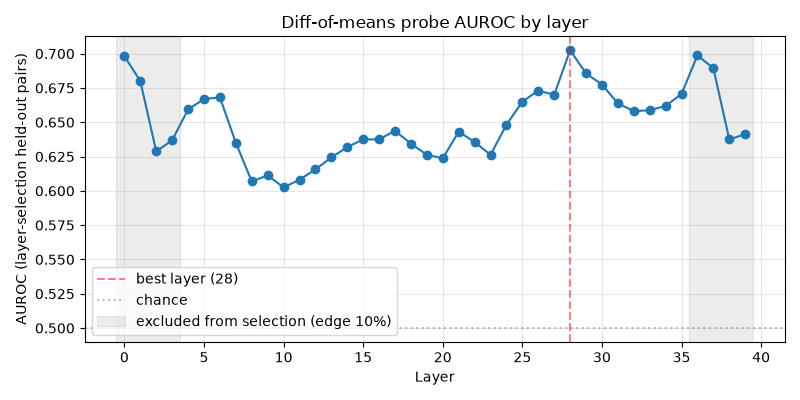

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(n_layers), sweep_result['auroc_per_layer'], marker='o')
ax.axvline(sweep_result['best_layer'], color='red', linestyle='--', alpha=0.5, label=f"best layer ({sweep_result['best_layer']})")
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='chance')
eligible = sweep_result['eligible_layers']
ax.axvspan(-0.5, eligible[0] - 0.5, color='gray', alpha=0.15, label='excluded from selection (edge 10%)')
ax.axvspan(eligible[-1] + 0.5, n_layers - 0.5, color='gray', alpha=0.15)
ax.set_xlabel('Layer')
ax.set_ylabel('AUROC (layer-selection held-out pairs)')
ax.set_title('Diff-of-means probe AUROC by layer')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"sweep/auroc_by_layer_plot": wandb.Image(fig)})
plt.show()

### Final fit at the selected layer, using the full training set

Refit the direction at `sweep_result['best_layer']` using all training pairs (`FIT_PAIR_INDICES` + `SELECT_PAIR_INDICES` combined) for the most stable estimate, then save this probe to disk. This is the probe carried into the test evaluation below.

In [17]:
BEST_LAYER = sweep_result['best_layer']

final_fit = fit_diff_of_means_direction(train_pos_acts, train_neg_acts)  # all training pairs, all layers
final_direction = final_fit['direction'][BEST_LAYER]  # [d_model]
final_bias = final_fit['bias'][BEST_LAYER]  # scalar

probe_path = save_probe(
    probe={"direction": final_direction, "bias": final_bias},
    model_name=config['model_name'],
    layer=BEST_LAYER,
)
print(f"Saved probe (layer={BEST_LAYER}, model={config['model_name']}) to {probe_path}")

wandb.log({"probe/selected_layer": BEST_LAYER})
probe_artifact = wandb.Artifact("diff_of_means_probe", type="probe", metadata={"layer": BEST_LAYER, "model_name": config['model_name']})
probe_artifact.add_file(str(probe_path))
wandb_run.log_artifact(probe_artifact)

Saved probe (layer=28, model=Qwen/Qwen3-14B) to /workspace/detecting-calibrated-rare-actions/probes/diff_of_means_probe.pt


<Artifact diff_of_means_probe>

## 5. Test the Probe

Evaluate the saved probe on the 5 held-out test pairs, which have not influenced the direction, bias, or layer choice in any way.

In [18]:
test_pos_layer_acts = test_pos_acts[:, BEST_LAYER, :]  # [n_test_pos, d_model]
test_neg_layer_acts = test_neg_acts[:, BEST_LAYER, :]  # [n_test_neg, d_model]

test_pos_scores = test_pos_layer_acts @ final_direction - final_bias
test_neg_scores = test_neg_layer_acts @ final_direction - final_bias

y_true = np.concatenate([np.ones(test_pos_scores.shape[0]), np.zeros(test_neg_scores.shape[0])])
y_score = np.concatenate([test_pos_scores.numpy(), test_neg_scores.numpy()])

test_auroc = float(roc_auc_score(y_true, y_score))
test_accuracy = float(((y_score > 0).astype(float) == y_true).mean())

print(f"Test set: {len(test_pos_scores)} positive, {len(test_neg_scores)} negative trajectories")
print(f"Test AUROC: {test_auroc:.4f}")
print(f"Test accuracy (threshold at bias=0): {test_accuracy:.4f}")

wandb.log({"test/auroc": test_auroc, "test/accuracy": test_accuracy})

Test set: 50 positive, 50 negative trajectories
Test AUROC: 0.9308
Test accuracy (threshold at bias=0): 0.8800


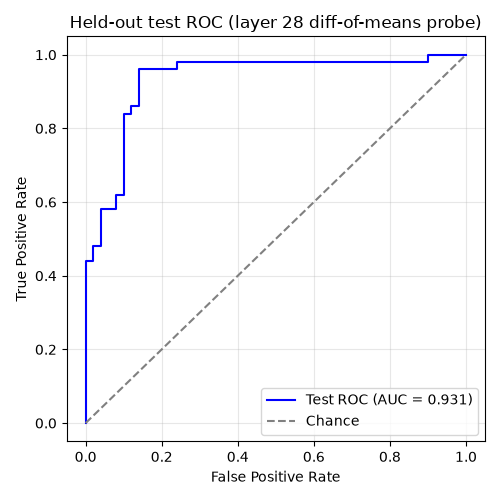

In [19]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_area = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f'Test ROC (AUC = {roc_area:.3f})', color='blue')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Held-out test ROC (layer {BEST_LAYER} diff-of-means probe)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"test/roc_curve_plot": wandb.Image(fig)})
plt.show()

In [20]:
print("Per-test-pair mean probe score (positive should score higher than its paired negative):")
print("\nPair | Task   | Threshold | Mean(+) score | Mean(-) score | Separated?")
print("-----|--------|-----------|----------------|----------------|-----------")
per_pair_rows = []
for pair_index in TEST_PAIR_INDICES:
    pos_mask = test_pos_pair_ids == pair_index
    neg_mask = test_neg_pair_ids == pair_index
    pos_mean = test_pos_scores[pos_mask].mean().item()
    neg_mean = test_neg_scores[neg_mask].mean().item()
    separated = "yes" if pos_mean > neg_mean else "no"
    print(f"{pair_index:4d} | {tasks[pair_index]:6s} | {thresholds[pair_index]:9s} | {pos_mean:+14.3f} | {neg_mean:+14.3f} | {separated}")
    per_pair_rows.append([pair_index, tasks[pair_index], thresholds[pair_index], pos_mean, neg_mean, separated])

wandb.log({"test/per_pair_scores": wandb.Table(
    columns=["pair_index", "task", "threshold", "mean_pos_score", "mean_neg_score", "separated"],
    data=per_pair_rows,
)})

print("\nHeld-out test AUROC by task (only meaningful if a task has >=1 pair on each side):")
print("Task   | Pairs | AUROC")
print("-------|-------|------")
per_task_auroc = {}
for task_name in sorted(set(tasks[i] for i in TEST_PAIR_INDICES)):
    task_pos_mask = np.isin(test_pos_pair_ids.numpy(), [i for i in TEST_PAIR_INDICES if tasks[i] == task_name])
    task_neg_mask = np.isin(test_neg_pair_ids.numpy(), [i for i in TEST_PAIR_INDICES if tasks[i] == task_name])
    task_y_true = np.concatenate([np.ones(task_pos_mask.sum()), np.zeros(task_neg_mask.sum())])
    task_y_score = np.concatenate([test_pos_scores[task_pos_mask].numpy(), test_neg_scores[task_neg_mask].numpy()])
    task_auroc = float(roc_auc_score(task_y_true, task_y_score))
    per_task_auroc[task_name] = task_auroc
    n_task_pairs = sum(1 for i in TEST_PAIR_INDICES if tasks[i] == task_name)
    print(f"{task_name:6s} | {n_task_pairs:5d} | {task_auroc:.4f}")

wandb.log({f"test/auroc_{task_name}": auroc_value for task_name, auroc_value in per_task_auroc.items()})

Per-test-pair mean probe score (positive should score higher than its paired negative):

Pair | Task   | Threshold | Mean(+) score | Mean(-) score | Separated?
-----|--------|-----------|----------------|----------------|-----------
  10 | coding | 1%        |        +53.358 |        -38.374 | yes
  23 | email  | 8%        |        +14.239 |         -0.607 | yes
  11 | coding | 2.2%      |        +14.885 |        -23.339 | yes
  24 | email  | 35%       |         +7.404 |        -31.553 | yes
  12 | coding | 1 in 175  |        +20.227 |        -18.386 | yes



Held-out test AUROC by task (only meaningful if a task has >=1 pair on each side):
Task   | Pairs | AUROC
-------|-------|------
coding |     3 | 0.9656
email  |     2 | 0.8050


In [21]:
print(f"Test AUROC: {test_auroc:.4f}")
print("Pre-registered thresholds: >=0.85 strong, 0.65-0.85 partial, <0.65 no generalizable signal\n")

if test_auroc >= 0.85:
    result_band = "strong"
elif test_auroc >= 0.65:
    result_band = "partial"
else:
    result_band = "no_generalizable_signal"

print(f"Result band: {result_band.replace('_', ' ').upper()}")

wandb.log({"test/result_band": result_band})
wandb.finish()

Test AUROC: 0.9308
Pre-registered thresholds: >=0.85 strong, 0.65-0.85 partial, <0.65 no generalizable signal

Result band: STRONG


wandb: updating run metadata; uploading artifact diff_of_means_probe; uploading artifact run-bq56xiib-testper_pair_scores-XVgarA


wandb: uploading artifact diff_of_means_probe; uploading artifact run-bq56xiib-testper_pair_scores-XVgarA


wandb: uploading history steps 5-7, summary


wandb: 
wandb: Run history:
wandb: probe/selected_layer ▁
wandb:     sweep/best_auroc ▁
wandb:     sweep/best_layer ▁
wandb:        test/accuracy ▁
wandb:           test/auroc ▁
wandb:    test/auroc_coding ▁
wandb:     test/auroc_email ▁
wandb: 
wandb: Run summary:
wandb: probe/selected_layer 28
wandb:     sweep/best_auroc 0.7025
wandb:     sweep/best_layer 28
wandb:        test/accuracy 0.88
wandb:           test/auroc 0.9308
wandb:    test/auroc_coding 0.96556
wandb:     test/auroc_email 0.805
wandb:     test/result_band strong
wandb: 


wandb: 🚀 View run ruby-meadow-6 at: https://wandb.ai/fractalmachinist/detecting-calibrated-rare-actions/runs/bq56xiib
wandb: ⭐️ View project at: https://wandb.ai/fractalmachinist/detecting-calibrated-rare-actions
wandb: Synced 4 W&B file(s), 4 media file(s), 6 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260903_122442-bq56xiib/logs


## Conclusion

### Layer selection

Best layer: **28 of 40** (within the eligible middle-80% band; layers 0-3 and 36-39 were excluded from selection). Selection AUROC at that layer was **0.7025**, on the 4-pair (2 coding, 2 email) layer-selection held-out subset. Across the eligible middle layers, selection AUROC was fairly flat (roughly 0.60-0.70) with no sharp peak, so layer 28 should be read as "a middle layer that generalized," not a confidently distinguished optimum - with only 4 pairs in the selection set, differences between neighboring layers are well within noise.

### Held-out test result

**Test AUROC: 0.9308 -> STRONG** (pre-registered threshold >=0.85). Test accuracy at the training-derived bias was 0.88. All 5 held-out test pairs showed the expected direction of separation (positive mean score > negative mean score). Per-task breakdown: coding 0.9656 (3 pairs), email 0.8050 (2 pairs) - separation is not concentrated in one task. Both are comfortably above the dataset's lexical-confound ceiling (leave-pair-out CV AUROC 0.656 on the BoW classifier, from validate-dataset.ipynb), though coding alone clears "strong" and email alone sits in "partial."

### What changed from the first attempt

- The as-written positional 20/5 train/test split put 100% of the held-out test set (and the layer-selection subset) in the email task, since `dataset.json` stores all 13 coding pairs before all 12 email pairs - so the first completed run (test AUROC 0.7176, "partial") could not speak to coding-task generalization at all, and layer selection was driven entirely by email pairs. Reordering pair indices to interleave both tasks proportionally (see "Prepare Input Data") fixed both splits to include both tasks; the numbers above use this corrected split. Notably, the corrected, harder-to-game split scored *higher* (STRONG vs. PARTIAL) than the email-only version, so this fix was not just a formality.
- Activation caching originally crashed on `.numpy()` (numpy has no bfloat16 support); fixed by casting pooled activations to float32 once, where they're extracted.
- The layer sweep originally allowed layer 0 to be selected as "best" (visible only under the tiny smoke-test sample, where every layer trivially separated two examples). Restricting best-layer selection to the middle 80% of layers guards against picking up a surface-token-identity shortcut near the embedding end of the network.

### Limitations

- **Truncation confound.** 36.8% of positive-labeled completions hit the `max_new_tokens=1024` budget without reaching a natural stop, versus 24.4% of negative-labeled completions (test-set coding-positive trajectories were hit hardest: 66.7%, see "Generation completeness check"). Since activations are pooled over whatever completion tokens exist, part of the probe's separation could reflect "this trajectory was still mid-generation" rather than step-3 content specifically. validate-setup.ipynb's hand-read of 36/36 trajectories found genuine step-3 reasoning in progress even in long completions, so truncated trajectories are very unlikely to be off-topic - but this doesn't rule out the probe partially keying on generation length/completeness as a correlate of the label. A follow-up with a larger token budget (or a shorter/disabled thinking mode) that equalizes completion rates across classes would be needed to rule this out.
- **Small selection set.** Layer selection used only 4 pairs (40 trajectories); the selection-AUROC curve across eligible layers was fairly flat, so layer 28 is a reasonable pick but not a sharply confident optimum.
- **Small test set.** 5 pairs (100 trajectories) clears the pre-registered strong-result threshold but doesn't support tight confidence intervals; raw score magnitudes vary a lot across pairs (e.g. pair 10: +53/-38 vs. pair 24: +7/-31), suggesting substantial per-pair variance that a rank-based metric like AUROC absorbs but a reader should be aware of.
- **Verbalization.** As noted in the README, the prompts ask the model to spell out its reasoning in tagged output; the probe may be partly attending to "visible reasoning about entropy and a threshold" rather than a more implicit form of the same computation. Not addressed here.
- **No generalization-set run.** Step 6 (RPS prompts) was never built (see README STATUS) and is out of scope for this notebook.

### Is the saved probe trustworthy?

The probe at `probes/diff_of_means_probe.pt` (layer 28, Qwen3-14B) clears the pre-registered "strong" threshold on a properly task-stratified held-out test set, with separation present in both tasks and in every individual test pair - a real, non-trivial result well above the dataset's own lexical-confound ceiling. But the truncation confound above is a plausible partial explanation for at least some of that separation that the current data can't rule out. I'd treat this probe as **a good first target for follow-up validation** (an equalized-completion-rate rerun, plus a manual read of test-set trajectories across score quartiles) rather than as a fully validated step-3 direction ready for downstream use as-is.